# Previsione dei Rendimenti del Bitcoin

**Realizzato da:** Tverdohleb Egor (Matricola: 0001114726)  
Email istituzionale: egor.tverdohleb@studio.unibo.it

## 1. Caricamento Librerie

Per prima cosa carichiamo le librerie fondamentali per effettuare le operazioni di manipolazione, analisi e visualizzazione grafica dei dati. 
 - *pandas*: Per il caricamento, la pulizia e la manipolazione di strutture dati tabulari
 - *numpy*: Per supportare il calcolo matematico e vettoriale su array a N dimensioni
 - *yfinance*: Per estrapolare in tempo reale i dati finanziari storici direttamente dalle API di Yahoo Finance.
 - *matplotlib.pyplot*: Per la generazione di grafici e report visivi

Abilitiamo inoltre l'inserimento dei grafici direttamente all'interno del notebook tramite `%matplotlib inline`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

%matplotlib inline

## 2. Caricamento e Analisi dei Dati

Procediamo all'estrazione dei dati storici relativi alla criptovaluta di cui vogliamo predirre il costo, il **Bitcoin**. Estraiamo un orizzonte temporale degli ultimi 5 anni, raccogliendo un volume di dati giornalieri sufficientemente ampio (oltre 1800 istanze).

### Significato delle colonne native di Yahoo Finance:
- `Open`: Prezzo di apertura della giornata finanziaria (espressa in USD)
- `High`: Prezzo massimo registrato durante la giornata
- `Low`: Prezzo minimo registrato durante la giornata
- `Close`: Prezzo di chiusura formale della giornata
- `Volume`: Volume monetario totale degli scambi registrati nelle 24 ore.
- `Dividends`: Dividendi distribuiti (tipico delle azioni, non applicabile alle crypto).
- `Stock Splits`: Frazionamenti azionari (non applicabile alle crypto).

In [2]:
print("Scaricamento dati")

btc = yf.Ticker("BTC-USD")
df = btc.history(period="5y")
display(df.tail())

Scaricamento dati


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2026-05-28 00:00:00+00:00,74339.570312,74460.125000,72493.414062,73536.554688,40148145327,0.0,0.0
2026-05-29 00:00:00+00:00,73537.031250,74218.562500,72435.625000,73372.523438,34457929250,0.0,0.0
2026-05-30 00:00:00+00:00,73370.851562,74020.757812,73125.234375,73754.835938,19563589191,0.0,0.0
2026-05-31 00:00:00+00:00,73753.750000,74153.500000,73315.015625,73579.687500,17445435650,0.0,0.0
2026-06-01 00:00:00+00:00,73568.398438,73874.750000,71467.593750,71518.023438,32269330432,0.0,0.0


### 2.1 Analisi Strutturale ed Eliminazione Ridondanze

Come evidenziato dall'anteprima del dataset, le colonne `Dividends` e `Stock Splits` presentano esclusivamente valori pari a `0.0` o `NaN`. Questo comportamento riflette l'asset class di riferimento: a differenza dei titoli azionari tradizionali, le criptovalute non distribuiscono dividendi societari né subiscono frazionamenti di capitale.

Al fine di ottimizzare lo spazio occupato in memoria e rimuovere feature prive di utilità, procediamo alla loro rimozione.

In [3]:
df.drop(columns=["Dividends", "Stock Splits"], inplace=True)
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1827 entries, 2021-06-01 00:00:00+00:00 to 2026-06-01 00:00:00+00:00
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    1827 non-null   float64
 1   High    1827 non-null   float64
 2   Low     1827 non-null   float64
 3   Close   1827 non-null   float64
 4   Volume  1827 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 85.6 KB


### 2.2 Semplificazione dei dati

Una caratteristica fondamentale delle criptovalute rispetto ai mercati tradizionali è l'operatività continua: i mercati crypto scambiano senza interruzioni.

Per verificare empiricamente l'efficienza informativa e la continuità dei prezzi, andiamo a calcolare la discrepanza percentuale tra il prezzo di chiusura (`Close`) di un giorno e il prezzo di apertura (`Open`) del giorno successivo. Se il mercato è perfettamente continuo e privo di interruzioni, questa differenza dovrebbe essere prossima allo zero.

In [4]:
df['Open_Tomorrow'] = df['Open'].shift(-1)
df['Gap_Percentuale'] = ((df['Open_Tomorrow'] - df['Close']) / df['Close']) * 100

print(df['Gap_Percentuale'].describe())

=== ANALISI DESCRITTIVA DEI GAP DI APERTURA/CHIUSURA ===
count    1826.000000
mean        0.003597
std         0.133066
min        -0.817254
25%        -0.007261
50%        -0.000283
75%         0.005496
max         3.791078
Name: Gap_Percentuale, dtype: float64


Come previsto la differenza media è virtualmente nulla, possiamo quindi rinominare la colonna Close in Prize per ridurre la ridondanza

In [5]:
df = df.rename(columns={'Close': 'Prize'})
df.drop(columns=['Open_Tomorrow', 'Gap_Percentuale', 'Open'], inplace=True)

### 2.3 Integrazione dei Dati di altre cryptovalute (Ethereum e Solana)

Per arricchire il contesto predittivo dell'algoritmo, andiamo a implementare un'analisi multi-asset. Il mercato delle criptovalute è fortemente interconnesso e dominato da trend globali. 

Scarichiamo i dati storici di altre due monete virtuali **Ethereum (ETH-USD)** e **Solana (SOL-USD)**, allineandole sul dataset principale.

In [6]:
print("Scaricamento dati per Ethereum e Solana")

eth = yf.Ticker("ETH-USD")
df_eth = eth.history(period="5y")[['Close']].rename(columns={'Close': 'Price_ETH'})

sol = yf.Ticker("SOL-USD")
df_sol = sol.history(period="5y")[['Close']].rename(columns={'Close': 'Price_SOL'})

df = df.join(df_eth, how='left')
df = df.join(df_sol, how='left')

df.head()

Scaricamento dati per Ethereum e Solana


,High,Low,Prize,Volume,Price_ETH,Price_SOL
Date,,,,,,
2021-06-01 00:00:00+00:00,37896.734375,35787.085938,36684.925781,34639423297,2633.518311,30.985260
2021-06-02 00:00:00+00:00,38231.339844,35966.308594,37575.179688,33070867190,2706.125000,33.956318
2021-06-03 00:00:00+00:00,39478.953125,37243.972656,39208.765625,35460750427,2855.126465,39.470905
2021-06-04 00:00:00+00:00,39242.484375,35717.722656,36894.406250,41831090187,2688.195068,37.415070
2021-06-05 00:00:00+00:00,37917.714844,34900.414062,35551.957031,35959473399,2630.576904,39.585400


### 2.4 Aggiunta Feature: Calcolo della Volatilità

La volatilità è una misura statistica fondamentale nei mercati finanziari, indicando il livello di incertezza e rischio. 
Andiamo a calcolare la volatilità storica su una finestra mobile di 30 giorni per tutti e tre gli asset. Utilizzeremo la formula del *range normalizzato di oscillazione giornaliera* (differenza percentuale massima tra High e Low rispetto al prezzo di chiusura), che esprime l'escursione dei prezzi indipendentemente dal loro valore assoluto in dollari.

In [7]:
range_btc = ((df['High'] - df['Low']) / df['Prize']) * 100
df['Volatility_30d'] = range_btc.rolling(window=30).mean()

eth_hist = eth.history(period="5y")
range_eth = ((eth_hist['High'] - eth_hist['Low']) / eth_hist['Close']) * 100
df['Volatility_ETH_30d'] = range_eth.rolling(window=30).mean()

sol_hist = sol.history(period="5y")
range_sol = ((sol_hist['High'] - sol_hist['Low']) / sol_hist['Close']) * 100
df['Volatility_SOL_30d'] = range_sol.rolling(window=30).mean()

df.tail()

,High,Low,Prize,Volume,Price_ETH,Price_SOL,Volatility_30d,Volatility_ETH_30d,Volatility_SOL_30d
Date,,,,,,,,,
2026-05-28 00:00:00+00:00,74460.125000,72493.414062,73536.554688,40148145327,2007.552734,81.985428,2.464088,3.259659,3.487368
2026-05-29 00:00:00+00:00,74218.562500,72435.625000,73372.523438,34457929250,2011.978516,81.932487,2.416357,3.186759,3.441024
2026-05-30 00:00:00+00:00,74020.757812,73125.234375,73754.835938,19563589191,2019.458252,82.547295,2.400368,3.166082,3.421525
2026-05-31 00:00:00+00:00,74153.500000,73315.015625,73579.687500,17445435650,2004.341553,82.298302,2.327484,3.136491,3.429680
2026-06-01 00:00:00+00:00,73874.750000,71467.593750,71518.023438,32269330432,1968.119995,79.650002,2.393578,3.150892,3.517403


## 2.5 Aggiunta feature: I Costi Energetici Globali

Per tentare di trovare un modello effettivamente predittivo cerchiamo di integrare dinamiche macroeconomiche legate al costo di estrazione della criptovaluta (*Proof of Work*), procediamo quindi integrando un indicatore energetico.

Utilizziamo i Futures del **Gas Naturale (NG=F)** come proxy per determinare l'andamento del costo dell'energia elettrica a livello globale. Risolviamo preventivamente le discrepanze di fuso orario ed effettuiamo un'operazione di *Forward Fill* seguita da *Backward Fill* per coprire le sessioni di chiusura del weekend tipiche dei mercati delle commodity tradizionali, garantendo un perfetto allineamento temporale con i mercati crypto.

In [8]:
energia = yf.Ticker("NG=F")
df_energia = energia.history(period="5y")

df.index = df.index.tz_localize(None)
df_energia.index = df_energia.index.tz_localize(None)

range_energia = ((df_energia['High'] - df_energia['Low']) / df_energia['Close']) * 100
df_energia['Volatility_Energy_30d'] = range_energia.rolling(window=30).mean()
df_energia = df_energia[['Close', 'Volatility_Energy_30d']].rename(columns={'Close': 'Price_Energy'})

df = df.join(df_energia, how='left')
df['Price_Energy'] = df['Price_Energy'].ffill().bfill()
df['Volatility_Energy_30d'] = df['Volatility_Energy_30d'].ffill().bfill()

display(df[['Prize', 'Price_Energy', 'Volatility_Energy_30d']].head())

,Prize,Price_Energy,Volatility_Energy_30d
Date,,,
2021-06-01,36684.925781,3.104,3.640051
2021-06-02,37575.179688,3.075,3.640051
2021-06-03,39208.765625,3.041,3.640051
2021-06-04,36894.406250,3.097,3.640051
2021-06-05,35551.957031,3.097,3.640051


## 3. Preparazione del Dataset

### 3.1 Calcolo dei Rendimenti e del Momentum Temporale

Per migliorare la capacità predittiva su un mercato che ha subito enormi variazioni di prezzo nel tempo, è fondamentale trasformare il dataset per lavorare su rendimenti percentuali. Questa operazione trasforma i prezzi grezzi in una serie storica stazionaria, requisito essenziale per garantire il corretto funzionamento dei modelli lineari ed evitare il fenomeno della regressione spuria.

Calcoliamo le variazioni percentuali a 1, 3 e 7 giorni per tutti gli asset (Bitcoin, Ethereum, Solana e Gas Naturale). Questo blocco di variabili quantifica il concetto di Momentum, ossia la tendenza dei mercati a seguire una direzione univoca per un breve lasso di tempo.

In [9]:
df['BTC_Return_1d'] = df['Prize'].pct_change(1) * 100
df['BTC_Return_3d'] = df['Prize'].pct_change(3) * 100
df['BTC_Return_7d'] = df['Prize'].pct_change(7) * 100

df['ETH_Return_1d'] = df['Price_ETH'].pct_change(1) * 100
df['ETH_Return_3d'] = df['Price_ETH'].pct_change(3) * 100
df['ETH_Return_7d'] = df['Price_ETH'].pct_change(7) * 100

df['SOL_Return_1d'] = df['Price_SOL'].pct_change(1) * 100
df['SOL_Return_3d'] = df['Price_SOL'].pct_change(3) * 100
df['SOL_Return_7d'] = df['Price_SOL'].pct_change(7) * 100

df['Energy_Return_1d'] = df['Price_Energy'].pct_change(1) * 100
df['Energy_Return_3d'] = df['Price_Energy'].pct_change(3) * 100
df['Energy_Return_7d'] = df['Price_Energy'].pct_change(7) * 100

df = df.dropna()
display(df[['Prize', 'Price_Energy', 'Volatility_Energy_30d', 'Energy_Return_1d']].head())

,Prize,Price_Energy,Volatility_Energy_30d,Energy_Return_1d
Date,,,,
2021-06-30,35040.835938,3.650,3.640051,0.550964
2021-07-01,33572.117188,3.661,3.640051,0.301368
2021-07-02,33897.046875,3.700,3.640051,1.065284
2021-07-03,34668.546875,3.700,3.640051,0.000000
2021-07-04,35287.781250,3.700,3.640051,0.000000


### 3.2 Generazione della Variabile Target con Spostamento Temporale

Il nostro obiettivo è usare le informazioni disponibili alla chiusura di oggi per prevedere il rendimento del Bitcoin di domani. Questo disallineamento temporale controllato costringe matematicamente l'algoritmo a effettuare una vera e propria previsione sul giorno successivo, rimuovendo le variabili assolute in dollari dalla matrice predittiva $X$.

In [10]:
df['Target_BTC_Return_Tomorrow'] = df['BTC_Return_1d'].shift(-1)

# Rimozione dell'ultima riga del dataset, che non possiede un target noto per il giorno successivo
df = df.dropna()

colonne_da_escludere = ['Target_BTC_Return_Tomorrow', 'High', 'Low', 'Prize', 'Price_ETH', 'Price_SOL', 'Price_Energy']
X = df.drop(columns=colonne_da_escludere)
y = df['Target_BTC_Return_Tomorrow']

print(f"Formato della matrice delle Feature (X): {X.shape} (Righe, Variabili Predittive)")
print(f"Formato del Target (y): {y.shape} (Risposte corrette)")
print("\nLe variabili che l'IA userà per predire il rendimento di domani sono:")
print(list(X.columns))

Formato della matrice delle Feature (X): (1797, 17) (Righe, Variabili Predittive)
Formato del Target (y): (1797,) (Risposte corrette)

Le variabili che l'IA userà per predire il rendimento di domani sono:
['Volume', 'Volatility_30d', 'Volatility_ETH_30d', 'Volatility_SOL_30d', 'Volatility_Energy_30d', 'BTC_Return_1d', 'BTC_Return_3d', 'BTC_Return_7d', 'ETH_Return_1d', 'ETH_Return_3d', 'ETH_Return_7d', 'SOL_Return_1d', 'SOL_Return_3d', 'SOL_Return_7d', 'Energy_Return_1d', 'Energy_Return_3d', 'Energy_Return_7d']


### 3.3 Suddivisione in Training Set e Test Set

Per convalidare i modelli predittivi effettuiamo un taglio netto impostando una proporzione del **70% per il Training Set** e il restante **30% per il Test Set**

In [11]:
split_index = int(len(df) * 0.70)

X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

print(f"Istanze totali nel dataset: {len(df)}")
print(f"Training Set (70%): {X_train.shape[0]} giorni (da {X_train.index[0].strftime('%Y-%m-%d')} a {X_train.index[-1].strftime('%Y-%m-%d')})")
print(f"Test Set (30%):     {X_test.shape[0]} giorni (da {X_test.index[0].strftime('%Y-%m-%d')} a {X_test.index[-1].strftime('%Y-%m-%d')})")

Istanze totali nel dataset: 1797
Training Set (70%): 1257 giorni (da 2021-06-30 a 2024-12-07)
Test Set (30%):     540 giorni (da 2024-12-08 a 2026-05-31)


## 4. Addestramento e Validazione dei Modelli Baseline

Andiamo ad addestrare e validare due modelli di natura algoritmica differente, calcolando le seguenti misure di performance: il **Mean Squared Error (MSE)**, il **Root Mean Squared Error (RMSE)** espresso nella scala percentuale corretta dei rendimenti, e il coefficiente di determinazione **$R^2$**.

1. **Regressione Lineare (Modello Lineare):**
2. **Random Forest Regressor (Modello Non Lineare):**

In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

def calcola_metriche(y_reale, y_predette, nome_modello):
    mse = mean_squared_error(y_reale, y_predette)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_reale, y_predette)
    
    print(f"Performance Modello: {nome_modello}")
    print(f"Mean Squared Error (MSE):  {mse:.5f}")
    print(f"Root MSE (RMSE):           {rmse:.4f}%")
    print(f"Coefficiente R²:           {r2:.5f}")
    print("-" * 40)
    return mse, rmse, r2

lr_mse, lr_rmse, lr_r2 = calcola_metriche(y_test, lr_preds, "Linear Regression")
rf_mse, rf_rmse, rf_r2 = calcola_metriche(y_test, rf_preds, "Random Forest")

Performance Modello: Linear Regression
Mean Squared Error (MSE):  5.49223
Root MSE (RMSE):           2.3436%
Coefficiente R²:           -0.01206
----------------------------------------
Performance Modello: Random Forest
Mean Squared Error (MSE):  6.55271
Root MSE (RMSE):           2.5598%
Coefficiente R²:           -0.20747
----------------------------------------


### 4.1 Discussione dei Risultati

Il test empirico dimostra che i modelli sviluppati non possiedono alcun reale potere predittivo. Questo risultato era statisticamente atteso considerando l'ipotesi di efficienza del mercato e il fenomeno del Random Walk. Nella teoria dei mercati efficienti in forma semi-forte, i rendimenti giornalieri degli asset speculativi liquidi si comportano come puro rumore bianco nel brevissimo termine. Un R2 vicino allo zero indica l'assoluta assenza di pattern lineari o non lineari interni facilmente sfruttabili

### 4.2 Analisi della Rilevanza delle Variabili

Andiamo ad analizzare la struttura interna del modello per estrarre l'importanza relativa delle feature. Questo ci permette di mappare quali indizi l'algoritmo reputi più utili per approssimare il rendimento futuro del Bitcoin.

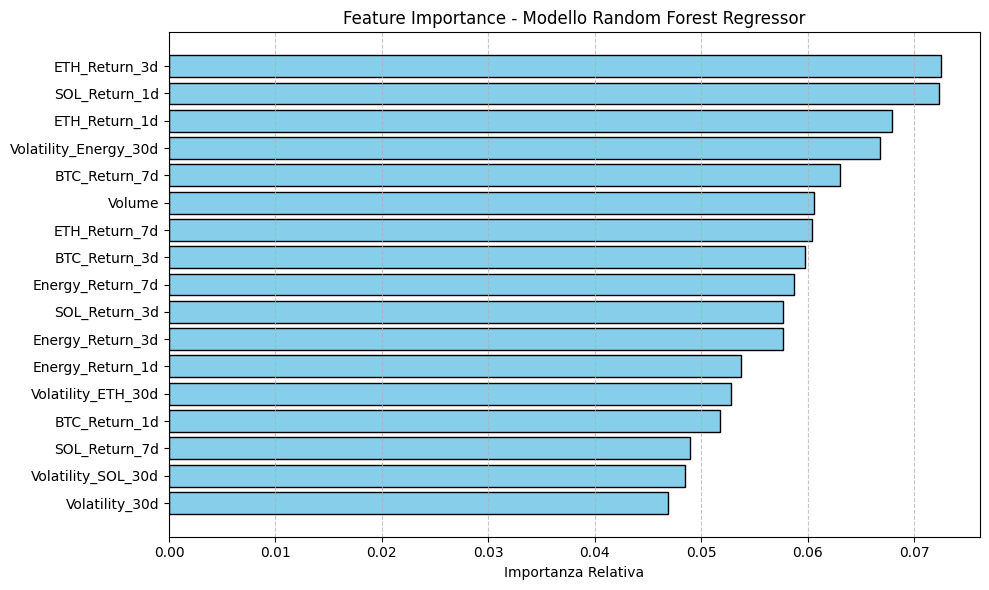

In [13]:
importances = rf_model.feature_importances_
features = X.columns

feature_imp_df = pd.DataFrame({'Feature': features, 'Importanza': importances})
feature_imp_df = feature_imp_df.sort_values(by='Importanza', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(feature_imp_df['Feature'], feature_imp_df['Importanza'], color='skyblue', edgecolor='black')
plt.xlabel('Importanza Relativa')
plt.title('Feature Importance - Modello Random Forest Regressor')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Il grafico rende chiaro che il modello non è riuscito a ricavare nessuna interazione non lineare rilevante. Dobbiamo quindi cambiare approccio se vogliamo riuscire ad estrapolare predizioni valide

## 5. Screening Massivo di Mercato

Verifichiamo la presenza di mercati in cui la correlazione sia tale da poter avere signifcato predittivo.

All'interno della cartella Dati sono presenti due Csv presi rispettivamente da [s&p](https://github.com/datasets/s-and-p-500-companies-financials/blob/main/data/constituents.csv) e [nasdaq](https://github.com/datasets/nasdaq-listings/blob/main/data/nasdaq-listed.csv), da essi possiamo estrarre una lista di quasi 6000 ticker azionari. Dopo aver eliminato tutti quelli che non presentavano abbastanza dati su yfinance ci rimangono **5048 ticker**, unendoli a commodity macro (Oro, Argento, Petrolio) e tassi di cambio Forex. L'algoritmo testerà ciclicamente gli asset per tentare di trovare correlazioni predittive.

In [14]:
import pandas as pd

ticker_totali = []

try:
    df_sp500_locale = pd.read_csv("data/sp500.csv")
    colonna_sp500 = 'Symbol' if 'Symbol' in df_sp500_locale.columns else df_sp500_locale.columns[0]
    ticker_sp500 = df_sp500_locale[colonna_sp500].dropna().tolist()
    
    ticker_sp500 = [str(t).replace('.', '-') for t in ticker_sp500]
    ticker_totali.extend(ticker_sp500)
    print(f"-> Caricati con successo {len(ticker_sp500)} ticker dallo S&P 500 locale.")
except Exception as e:
    print(f"Errore nel caricamento di sp500.csv: {e}. Assicurati che il file sia nella stessa cartella.")

try:
    df_nasdaq_locale = pd.read_csv("data/nasdaq.csv")
    colonna_nasdaq = 'Symbol' if 'Symbol' in df_nasdaq_locale.columns else df_nasdaq_locale.columns[0]
    ticker_nasdaq = df_nasdaq_locale[colonna_nasdaq].dropna().tolist()
    
    ticker_nasdaq = [str(t).replace('.', '-') for t in ticker_nasdaq]
    ticker_totali.extend(ticker_nasdaq)
    print(f"-> Caricati con successo {len(ticker_nasdaq)} ticker dal NASDAQ 100 locale.")
except Exception as e:
    print(f"Errore nel caricamento di nasdaq100.csv: {e}. Assicurati che il file sia nella stessa cartella.")

macro_ticker = ["GC=F", "SI=F", "CL=F", "NG=F", "^DJI", "^VIX", "EURUSD=X", "GBPUSD=X"]
ticker_totali.extend(macro_ticker)

ticker_totali = list(set(ticker_totali))
print(f"\n[OK] Database dei ticker completato! Totale asset unici pronti allo screening: {len(ticker_totali)}")

-> Caricati con successo 490 ticker dallo S&P 500 locale.
-> Caricati con successo 4702 ticker dal NASDAQ 100 locale.

[OK] Database dei ticker completato! Totale asset unici pronti allo screening: 5048


### 5.1 Esecuzione del Ciclo di Screening ad Alte Prestazioni

Per ogni asset, il codice eseguirà l'allineamento dei fusi orari, colmerà i buchi informativi dei weekend finanziari tramite *Forward Fill*, calcolerà il Momentum a 1, 3 e 7 giorni e addestrerà una pipeline composta da `StandardScaler` e `Ridge Regression`. I modelli verranno regolarizzati pesantemente con `alpha=1000.0` per ripulire il rumore di fondo. Lo script memorizzerà esclusivamente i mercati in grado di rompere la barriera dello zero e registrare un $R^2$ positivo sul test set di validazione.

In [15]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score
import yfinance as yf
import numpy as np
import sys
import time

df_base = df.copy()
colonne_vecchie = [c for c in df_base.columns if 'Energy' in c or 'Cand' in c]
df_base = df_base.drop(columns=colonne_vecchie)
df_base.index = df_base.index.tz_localize(None)

mercati_vincenti = {}
total_ticker = len(ticker_totali)

start_time = time.time()

for index, ticker in enumerate(ticker_totali):
    
    if index % 500 == 0 and index > 0:
        percentuale = (index / total_ticker) * 100
        tempo_trascorso = time.time() - start_time
        tempo_stimato_totale = (tempo_trascorso / index) * total_ticker
        tempo_rimanente = tempo_stimato_totale - tempo_trascorso
        
        print(f"[Avanzamento] Elaborati: {index}/{total_ticker} ({percentuale:.1f}%) | "
              f"Tempo passato: {tempo_trascorso/60:.1f} min | Rimangono circa: {tempo_rimanente/60:.1f} min")
        
    try: 
        asset_tick = yf.Ticker(ticker)
        df_cand = asset_tick.history(period="5y")
        
        if df_cand.empty or len(df_cand) < 100 or 'Close' not in df_cand.columns: 
            print(f"Skipping {ticker}",end=" ")
            if(df_cand.empty):print("empty")
            elif(len(df_cand) < 100):print("< 100")
            elif('Close' not in df_cand.columns):print("No close")
            continue
            
        df_cand.index = df_cand.index.tz_localize(None)
        
        range_cand = ((df_cand['High'] - df_cand['Low']) / df_cand['Close']) * 100
        df_cand['Volatility_Cand_30d'] = range_cand.rolling(window=30).mean()
        df_cand = df_cand[['Close', 'Volatility_Cand_30d']].rename(columns={'Close': 'Price_Cand'})
        
        df_test = df_base.join(df_cand, how='left')
        df_test['Price_Cand'] = df_test['Price_Cand'].ffill().bfill()
        df_test['Volatility_Cand_30d'] = df_test['Volatility_Cand_30d'].ffill().bfill()
        
        df_test['Cand_Return_1d'] = df_test['Price_Cand'].pct_change(1) * 100
        df_test['Cand_Return_3d'] = df_test['Price_Cand'].pct_change(3) * 100
        df_test['Cand_Return_7d'] = df_test['Price_Cand'].pct_change(7) * 100
        df_test = df_test.dropna()
        
        colonne_escludere = ['Target_BTC_Return_Tomorrow', 'High', 'Low', 'Prize', 'Price_ETH', 'Price_SOL', 'Price_Cand']
        X_loop = df_test.drop(columns=[c for c in colonne_escludere if c in df_test.columns])
        y_loop = df_test['Target_BTC_Return_Tomorrow']
        
        split_idx = int(len(df_test) * 0.70)
        X_tr, X_te = X_loop.iloc[:split_idx], X_loop.iloc[split_idx:]
        y_tr, y_te = y_loop.iloc[:split_idx], y_loop.iloc[split_idx:]
        
        model_loop = Pipeline([
            ('scaler', StandardScaler()),
            ('ridge', Ridge(alpha=1000.0))
        ])
        model_loop.fit(X_tr, y_tr)
        preds_loop = model_loop.predict(X_te)
        
        r2_sc = r2_score(y_te, preds_loop)
        
        if r2_sc > 0:
            mercati_vincenti[ticker] = r2_sc
            
    except Exception as e:
        print(f"Error skipping {ticker} : {e}")
        continue

print(f"Totale mercanti vincenti {len(mercati_vincenti)}")
if mercati_vincenti:
    for t, score in sorted(mercati_vincenti.items(), key=lambda item: item[1], reverse=True):
        print(f" - Ticker: {t} | R² sul Test Set: {score:.5f}")
else:
    print("Nessun mercato ha mostrato un R² maggiore di zero.")

[Avanzamento] Elaborati: 500/5048 (9.9%) | Tempo passato: 1.5 min | Rimangono circa: 13.4 min
[Avanzamento] Elaborati: 1000/5048 (19.8%) | Tempo passato: 2.9 min | Rimangono circa: 11.7 min
[Avanzamento] Elaborati: 1500/5048 (29.7%) | Tempo passato: 4.4 min | Rimangono circa: 10.3 min
[Avanzamento] Elaborati: 2000/5048 (39.6%) | Tempo passato: 5.9 min | Rimangono circa: 8.9 min
[Avanzamento] Elaborati: 2500/5048 (49.5%) | Tempo passato: 7.4 min | Rimangono circa: 7.5 min
[Avanzamento] Elaborati: 3000/5048 (59.4%) | Tempo passato: 8.9 min | Rimangono circa: 6.1 min
[Avanzamento] Elaborati: 3500/5048 (69.3%) | Tempo passato: 10.4 min | Rimangono circa: 4.6 min
[Avanzamento] Elaborati: 4000/5048 (79.2%) | Tempo passato: 11.8 min | Rimangono circa: 3.1 min
[Avanzamento] Elaborati: 4500/5048 (89.1%) | Tempo passato: 13.4 min | Rimangono circa: 1.6 min
[Avanzamento] Elaborati: 5000/5048 (99.0%) | Tempo passato: 14.8 min | Rimangono circa: 0.1 min
Totale mercanti vincenti 43
 - Ticker: WVVI |

### 5.2 Analisi Empirica delle Anomalie di Mercato Isolate

Al termine dello screening, l'algoritmo ha isolato esattamente **43 asset** capaci di registrare un $R^2$ positivo sul test set, violando l'ipotesi di efficienza pura. Questi asset fanno parte dei più disparati gruppo macroeconomici dimostrato che le imperfezioni del mercato non sono facilmente scovabili con ragionamenti intuitivi.

## 6. Ottimizzazione degli Iperparametri (Grid Search)

Andiamo a effettuare l'ottimizzazione degli iperparametri del nostro modello lineare baseline. 

Utilizziamo la struttura robusta della **Ridge Regression** inserita in una pipeline di standardizzazione (`StandardScaler`) ed eseguiamo una ricerca esaustiva (`GridSearchCV`) sul parametro di penalizzazione L2 `alpha`.

Essendo questo un processo computazionalmente costoso lo andiamo ad applicare sulle sole top 10 candidate estratte nel passagio precedente.

In [16]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error
import pandas as pd
import numpy as np
import yfinance as yf

if not mercati_vincenti:
    print("[ATTENZIONE] Lo screener non ha isolato nessun mercato con R² > 0.")
    top_10_tickers = []
else:
    top_10_ordinati = sorted(mercati_vincenti.items(), key=lambda item: item[1], reverse=True)[:10]
    top_10_tickers = [item[0] for item in top_10_ordinati]
    print(f"[OK] Avvio analisi comparativa indipendente sulle TOP 10 anomalie esogene:\n{top_10_tickers}\n")

record_finali = []

for ticker in top_10_tickers:
    try:
        ticker_obj = yf.Ticker(ticker)
        df_cand = ticker_obj.history(period="5y")
        
        if df_cand.empty:
            continue
            
        df_cand.index = df_cand.index.tz_localize(None)
        
        range_esogeno = ((df_cand['High'] - df_cand['Low']) / df_cand['Close']) * 100
        vol_col = f'Volatility_{ticker}_30d'
        price_col = f'Price_{ticker}'
        
        df_cand[vol_col] = range_esogeno.rolling(window=30).mean()
        df_cand = df_cand[['Close', vol_col]].rename(columns={'Close': price_col})
        
        df_loop = df_base.join(df_cand, how='left')
        df_loop[price_col] = df_loop[price_col].ffill().bfill()
        df_loop[vol_col] = df_loop[vol_col].ffill().bfill()
        
        df_loop[f'{ticker}_Return_1d'] = df_loop[price_col].pct_change(1) * 100
        df_loop[f'{ticker}_Return_3d'] = df_loop[price_col].pct_change(3) * 100
        df_loop[f'{ticker}_Return_7d'] = df_loop[price_col].pct_change(7) * 100
        
        df_loop['Target_BTC_Return_Tomorrow'] = df_loop['BTC_Return_1d'].shift(-1)
        df_loop = df_loop.dropna()
        
        colonne_utili = [
            'BTC_Return_1d', 'Volatility_30d',
            vol_col, f'{ticker}_Return_1d', f'{ticker}_Return_3d', f'{ticker}_Return_7d'
        ]
        
        X_f = df_loop[colonne_utili]
        y_f = df_loop['Target_BTC_Return_Tomorrow']
        
        split_idx = int(len(df_loop) * 0.70)
        X_train_f, X_test_f = X_f.iloc[:split_idx], X_f.iloc[split_idx:]
        y_train_f, y_test_f = y_f.iloc[:split_idx], y_f.iloc[split_idx:]
        
        pipeline_baseline = Pipeline([
            ('scaler', StandardScaler()),
            ('ridge', Ridge(alpha=1000.0))
        ])
        pipeline_baseline.fit(X_train_f, y_train_f)
        preds_base = pipeline_baseline.predict(X_test_f)
        
        r2_pre = r2_score(y_test_f, preds_base)
        rmse_pre = np.sqrt(mean_squared_error(y_test_f, preds_base))
        
        pipeline_gs = Pipeline([
            ('scaler', StandardScaler()),
            ('ridge', Ridge())
        ])
        param_grid = {'ridge__alpha': [0.1, 1.0, 10.0, 50.0, 100.0, 500.0, 1000.0, 2500.0, 5000.0, 7500.0, 10000.0]}
        
        grid_search = GridSearchCV(estimator=pipeline_gs, param_grid=param_grid, cv=5, scoring='neg_mean_squared_error')
        grid_search.fit(X_train_f, y_train_f)
        
        best_alpha = grid_search.best_params_['ridge__alpha']
        best_model = grid_search.best_estimator_
        preds_opt = best_model.predict(X_test_f)
        
        r2_post = r2_score(y_test_f, preds_opt)
        rmse_post = np.sqrt(mean_squared_error(y_test_f, preds_opt))
        
        record_finali.append({
            "Ticker": ticker,
            "R² Pre-GS (α=1000)": f"{r2_pre:.5f}",
            "R² Post-GS": f"{r2_post:.5f}",
            "Miglior Alpha": best_alpha,
            "RMSE Pre (%)": f"{rmse_pre:.4f}%",
            "RMSE Post (%)": f"{rmse_post:.4f}%"
        })
        print(f"[DONE] Elaborato Ticker {ticker:7} -> Miglior Alpha: {best_alpha:6} | R² Post: {r2_post:.5f}")
        
    except Exception as e:
        print(f"[ERR] Errore nell'elaborazione del ticker {ticker}: {e}")

print("\n" + "="*80)
print("             TABELLA COMPARATIVA FINALE: PRE VS POST GRID SEARCH")
print("="*80)
df_comparativo = pd.DataFrame(record_finali)
display(df_comparativo)

[OK] Avvio analisi comparativa indipendente sulle TOP 10 anomalie esogene:
['WVVI', 'FMC', 'COLM', 'TSLS', 'AXON', 'MTEN', 'MYCM', 'VCRB', 'BRTR', 'CLYM']

[DONE] Elaborato Ticker WVVI    -> Miglior Alpha: 2500.0 | R² Post: 0.00776
[DONE] Elaborato Ticker FMC     -> Miglior Alpha: 7500.0 | R² Post: 0.00383
[DONE] Elaborato Ticker COLM    -> Miglior Alpha: 10000.0 | R² Post: 0.00019
[DONE] Elaborato Ticker TSLS    -> Miglior Alpha: 5000.0 | R² Post: 0.00359
[DONE] Elaborato Ticker AXON    -> Miglior Alpha: 1000.0 | R² Post: 0.00417
[DONE] Elaborato Ticker MTEN    -> Miglior Alpha: 10000.0 | R² Post: -0.00046
[DONE] Elaborato Ticker MYCM    -> Miglior Alpha: 10000.0 | R² Post: -0.00222
[DONE] Elaborato Ticker VCRB    -> Miglior Alpha: 10000.0 | R² Post: -0.00169
[DONE] Elaborato Ticker BRTR    -> Miglior Alpha: 10000.0 | R² Post: -0.00150
[DONE] Elaborato Ticker CLYM    -> Miglior Alpha: 1000.0 | R² Post: 0.00630

             TABELLA COMPARATIVA FINALE: PRE VS POST GRID SEARCH


,Ticker,R² Pre-GS (α=1000),R² Post-GS,Miglior Alpha,RMSE Pre (%),RMSE Post (%)
0,WVVI,0.01023,0.00776,2500.0,2.3153%,2.3182%
1,FMC,0.01307,0.00383,7500.0,2.3119%,2.3227%
2,COLM,0.01083,0.00019,10000.0,2.3146%,2.3270%
3,TSLS,0.00982,0.00359,5000.0,2.3158%,2.3230%
4,AXON,0.00417,0.00417,1000.0,2.3224%,2.3224%
5,MTEN,0.00865,-0.00046,10000.0,2.3171%,2.3277%
6,MYCM,0.00203,-0.00222,10000.0,2.3248%,2.3298%
7,VCRB,0.00561,-0.00169,10000.0,2.3207%,2.3292%
8,BRTR,0.00530,-0.00150,10000.0,2.3210%,2.3290%
9,CLYM,0.00630,0.00630,1000.0,2.3199%,2.3199%


I risultati della Grid Search svelano un retroscena interessante. Parte degli R2 positivi registrati durante lo screening massivo erano probabilmente frutto di un disallineamento temporale (mercati azionari chiusi nei weekend).
La Cross-Validation ha smascherato questo rumore di fondo. Per proteggere il modello da queste finte correlazioni, l'algoritmo ha innalzato il parametro α fino a 10.000 per spegnere l'impatto di molti asset, portando il loro R2 sotto lo zero. Tuttavia, questo filtro ci ha permesso di certificare le uniche e vere anomalie strutturali che hanno resistono alla penalizzazione

### 6.1 Analisi Tabellare e Visualizzazione delle Performance sulla Griglia

Generiamo un grafico per rappresentare visivamente gli unici mercati abbastanza correlati per avere potere predittivo tramite il nostro modello

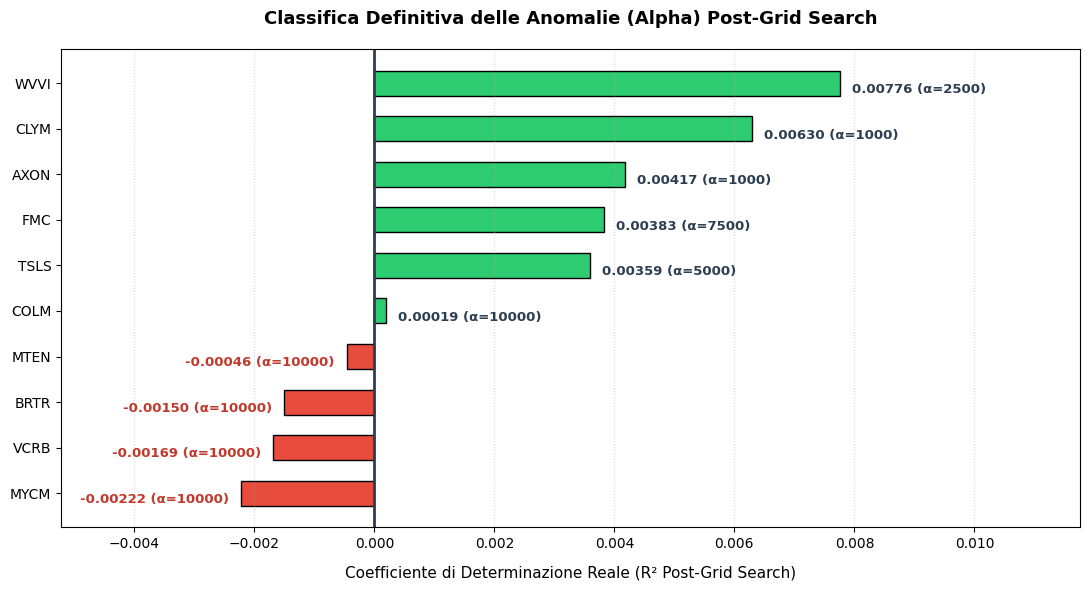

In [18]:
import matplotlib.pyplot as plt
import numpy as np

if 'record_finali' not in locals() or not record_finali:
    print("[ATTENZIONE] Nessun dato disponibile nei record della Grid Search.")
    print("Esegui prima il blocco precedente con il ciclo delle Top 10 per generare questo grafico.")
else:
    ticker_nomi = [r["Ticker"] for r in record_finali]
    r2_punteggi = [float(r["R² Post-GS"]) for r in record_finali]
    alphas_scelti = [r["Miglior Alpha"] for r in record_finali]

    dati_ordinati = sorted(zip(ticker_nomi, r2_punteggi, alphas_scelti), key=lambda x: x[1], reverse=True)
    ticker_nomi = [x[0] for x in dati_ordinati]
    r2_punteggi = [x[1] for x in dati_ordinati]
    alphas_scelti = [x[2] for x in dati_ordinati]

    ticker_nomi.reverse()
    r2_punteggi.reverse()
    alphas_scelti.reverse()

    plt.figure(figsize=(11, 6))

    colori = ['#2ecc71' if r2 > 0 else '#e74c3c' for r2 in r2_punteggi]
    
    bars = plt.barh(ticker_nomi, r2_punteggi, color=colori, edgecolor='black', height=0.55)
    
    plt.axvline(0, color='#2c3e50', linestyle='-', linewidth=2)

    for i, bar in enumerate(bars):
        width = bar.get_width()
        if width >= 0:
            plt.text(width + 0.0002, bar.get_y() + bar.get_height()/4, 
                     f'{width:.5f} (α={int(alphas_scelti[i])})', 
                     va='center', ha='left', fontsize=9.5, fontweight='semibold', color='#2c3e50')
        else:
            plt.text(width - 0.0002, bar.get_y() + bar.get_height()/4, 
                     f'{width:.5f} (α={int(alphas_scelti[i])})', 
                     va='center', ha='right', fontsize=9.5, fontweight='semibold', color='#c0392b')

    
    plt.xlabel('Coefficiente di Determinazione Reale (R² Post-Grid Search)', fontsize=11, labelpad=10)
    plt.title("Classifica Definitiva delle Anomalie (Alpha) Post-Grid Search", fontsize=13, fontweight='bold', pad=18)
    
    plt.xlim(min(r2_punteggi) - 0.003, max(r2_punteggi) + 0.004)
    plt.grid(axis='x', linestyle=':', alpha=0.5)

    plt.tight_layout()
    plt.show()

## 7. Conclusioni e Considerazioni Finali

Tramite l'analisi di alcuni dati finanziari e l'applicazioni di semplci analisi di regressione siamo riusciti ad estrapolare alcune correlazioni di tipo predittivo.

Pur essendo questo un semplice esercizio ben lontano dalla creazione di una strategia di trading quantitativo reale mi ritengo soddisfatto del risultato ottenuto.

Il progetto potrebbe essere espanso cercando di generalizzare ed affinare l'approcio seguito per trovare correlazioni più significative all'interno dei mercati azionari